In [1]:
# Imports
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import datasets
from sklearn.metrics.pairwise import cosine_similarity, cosine_distances
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn import svm
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score, f1_score, v_measure_score, pairwise_kernels, pairwise_distances
from sklearn.model_selection import train_test_split
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.decomposition import KernelPCA
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KNeighborsClassifier
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import scipy.spatial.distance as ssd
import statsmodels.api as sm
from dtaidistance import dtw, dtw_ndim
from dtaidistance import dtw_visualisation as dtwvis
from tck.TCK import TCK
from tck.datasets import DataLoader
from reservoir_computing.reservoir import Reservoir
from reservoir_computing.tensorPCA import tensorPCA
from reservoir_computing.modules import RC_model
from reservoir_computing.utils import compute_test_scores
import time

## Упражнение 1

1. Вычислите матрицу расстояний DTW.
2. Получите из нее матрицу сходства.
3. Постройте две матрицы. Прокомментируйте структуру, которую вы видите (не забудьте отсортировать элементы по классам).
4. Выполните классификацию с помощью классификаторов SVC и $k$-NN и сообщите:
- время обучения и тестирования,
- точность и оценку F1 на тестовом наборе.
5. Выполните иерархическую кластеризацию с помощью алгоритма Linkage Ward.
6. Постройте дендрограмму и проверьте ее, чтобы выбрать оптимальный порог для генерации кластерного раздела. Сообщите NMI для найденного вами раздела.
7. Выполните снижение размерности с помощью KernelPCA. Постройте результаты на двумерном графике.

In [2]:
Xtr, Ytr, Xte, Yte = DataLoader().get_data('Libras')

Loaded Libras dataset.
Number of classes: 15
Data shapes:
  Xtr: (180, 45, 2)
  Ytr: (180, 1)
  Xte: (180, 45, 2)
  Yte: (180, 1)


### 1. Матрица расстояний

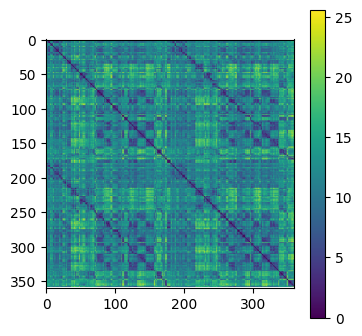

In [5]:
X = np.concatenate((Xtr, Xte), axis=0)
Y = np.concatenate((Ytr, Yte), axis=0)

# Compute the distance matrix
dtw_dist = dtw_ndim.distance_matrix_fast(X)

# Plot the distance matrix
plt.figure(figsize=(4,4))
plt.imshow(dtw_dist, cmap='viridis')
plt.colorbar()

plt.show()

Синие блоки на диагонали это образцы одного класса близкие друг к другу, в матрице видна четкая блочная структура

### 2. Матрица сходств

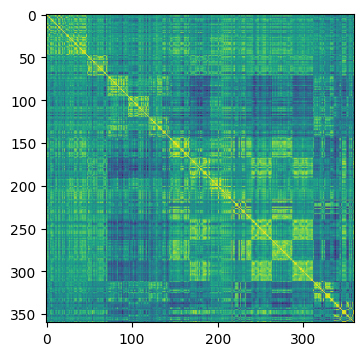

In [44]:
dtw_sim = 1.0 - dtw_dist/dtw_dist.max()

# Plot the similarity matrix
idx_sorted = np.argsort(Y[:,0])
dtw_sim_sorted = dtw_sim[:,idx_sorted][idx_sorted,:]
fig =  plt.figure(figsize=(4,4))
plt.imshow(dtw_sim_sorted)

Желтые блоки расположенные на диагонали говорят о высоком сходстве внутри классов, а синие о низком. Можно четко выделить 10 классов (желто-зеленые квадраты на диагонали)

In [45]:
sim_trtr = dtw_sim[:Xtr.shape[0], :Xtr.shape[0]]
print(sim_trtr.shape)

sim_tetr = dtw_sim[Xtr.shape[0]:, :Xtr.shape[0]]
print(sim_tetr.shape)

(180, 180)
(180, 180)


### 4.1 Классификация с помощью классификатора SVC

In [51]:
s = time.time()
clf = svm.SVC(kernel='precomputed', C=1).fit(sim_trtr, Ytr.ravel())
f = time.time() - s
y_pred = clf.predict(sim_tetr)
accuracy = accuracy_score(Yte.ravel(), y_pred)
f1 = f1_score(Yte.ravel(), y_pred, average='macro')
print(f"Accuracy: {accuracy*100:.2f}%, F1_score: {f1*100:.2f}%", f"Время обучения и тестирования: {time.time() - s}")


Accuracy: 74.44%, F1_score: 73.87% Время обучения и тестирования: 0.007300853729248047


### 4.2 Классификацию с помощью классификатора $k$-NN

In [52]:
# In this case we use the DTW distance directly.
dtw_trtr = dtw_dist[:Xtr.shape[0], :Xtr.shape[0]]
dtw_tetr = dtw_dist[Xtr.shape[0]:, :Xtr.shape[0]]

In [56]:
s = time.time()
neigh = KNeighborsClassifier(n_neighbors=3, metric='precomputed') # specify k=3
neigh.fit(dtw_trtr, Ytr.ravel())
y_pred = neigh.predict(dtw_tetr)
accuracy = accuracy_score(Yte.ravel(), y_pred)
f1 = f1_score(Yte.ravel(), y_pred, average='macro')
print(f"Accuracy: {accuracy*100:.2f}%, F1_score: {f1*100:.2f}%", f"Время обучения и тестирования: {time.time() - s} сек.")

Accuracy: 83.33%, F1_score: 82.78% Время обучения и тестирования: 0.00827479362487793 сек.


### 5. Иерархическая кластеризация

In [66]:
X_vectors = Xtr.reshape(Xtr.shape[0], -1)

X_final = StandardScaler().fit_transform(X_vectors)

Dist = pairwise_distances(X_final, metric="sqeuclidean")
distArray = ssd.squareform(Dist)

# Compute the hierarchy of clusters
Z = linkage(distArray, 'ward')

In [73]:
partition_1 = fcluster(Z, t=20, criterion="distance")
print("Partition 1: %d clusters"%len(np.unique(partition_1)))

partition_2 = fcluster(Z, t=290, criterion="distance")
print("Partition 1: %d clusters"%len(np.unique(partition_2)))

Partition 1: 110 clusters
Partition 1: 15 clusters


In [74]:
def plot_clusters(data, clusters=None, title=None, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    color = 'gray' if clusters is None else plt.cm.tab10(clusters)
    ax.scatter(data[:, 0], data[:, 1], c=color, s=15, alpha=0.5)
    ax.set_xticks(())
    ax.set_yticks(())
    ax.spines[['right', 'left', 'top', 'bottom']].set_visible(False)
    ax.set_title(title)

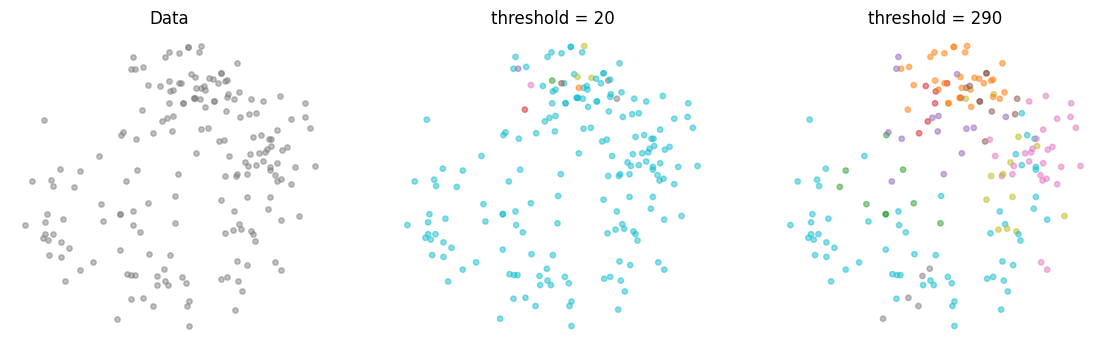

In [78]:
_, axes = plt.subplots(1,3, figsize=(14,4))
plot_clusters(X_final, title="Data", ax=axes[0])
plot_clusters(X_final, title="threshold = 20", clusters=partition_1, ax=axes[1])
plot_clusters(X_final, title="threshold = 290", clusters=partition_2, ax=axes[2])

### 6. Дендограмма

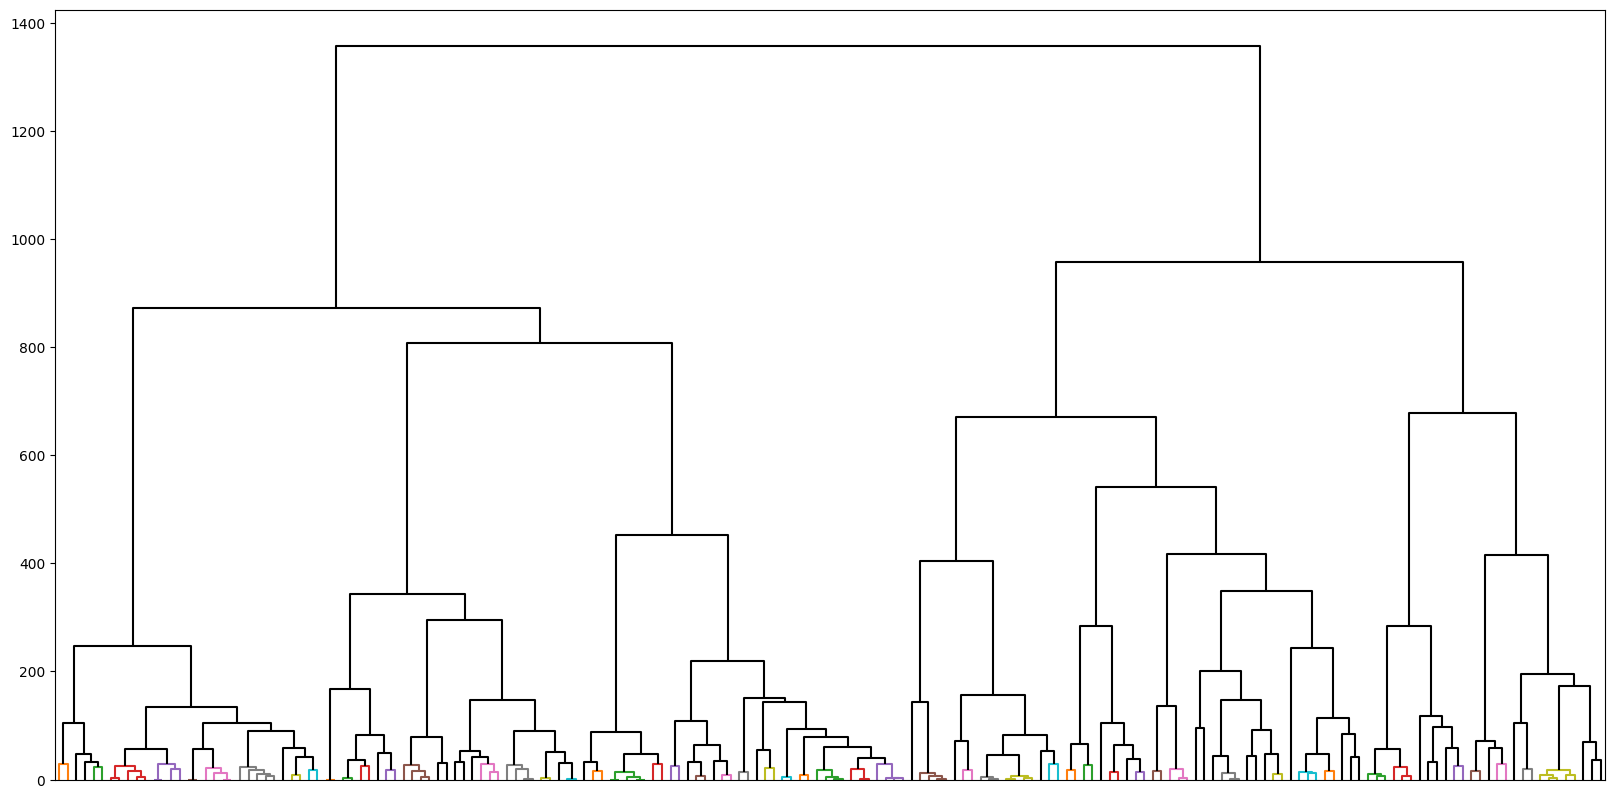

In [79]:
fig = plt.figure(figsize=(20, 10))
dn = dendrogram(Z, color_threshold=30, above_threshold_color='k',
                show_leaf_counts=False)
plt.xticks([])
plt.show()

In [93]:
partition = fcluster(Z, t=350, criterion="distance")
print(f"Found {len(np.unique(partition))} clusters")

Found 12 clusters


In [94]:
print(f"DTW-based clustering NMI: {v_measure_score(partition, Ytr.ravel()):.2f}")

DTW-based clustering NMI: 0.58


### 7. Снижение размерности

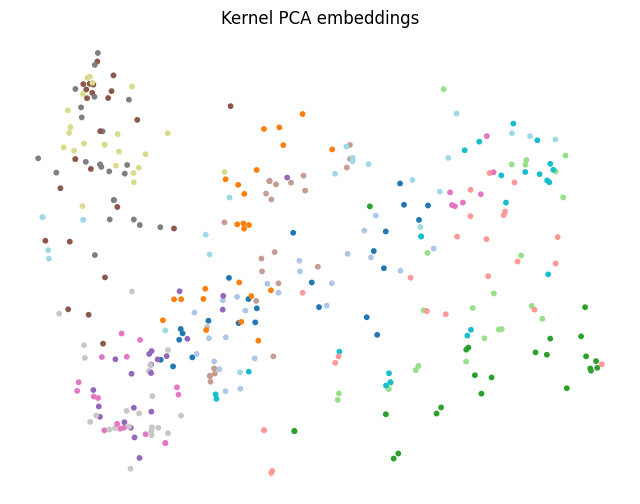

In [95]:
kpca = KernelPCA(n_components=2, kernel='precomputed')
embeddings_pca = kpca.fit_transform(dtw_sim)

fig =  plt.figure(figsize=(8,6))
plt.scatter(embeddings_pca[:,0], embeddings_pca[:,1], c=Y.ravel(), s=10, cmap='tab20')
plt.title("Kernel PCA embeddings")
plt.gca().spines[['right', 'left', 'top', 'bottom']].set_visible(False)
plt.xticks(())
plt.yticks(());

## Упражнение 2

1. Добавьте 40% пропущенных значений к обучающим и тестовым данным.
2. Вычислите ядро ​​TCK.
3. Вычислите матрицу различий из ядра (попробуйте сделать дополнительное к тому, что вы сделали для получения сходства из DTW).

Повторите пункты 4–7 из предыдущего упражнения.

### 1. Пропуски в данных

In [3]:
mask_tr = np.random.choice([0, 1], size=Xtr.shape, p=[0.6, 0.4])
Xtr[mask_tr == 1] = np.nan
mask_te = np.random.choice([0, 1], size=Xte.shape, p=[0.6, 0.4])
Xte[mask_te == 1] = np.nan

### 2. Ядро TCK

In [4]:
tck = TCK(G=30, C=15)
Ktr = tck.fit(Xtr).predict(mode='tr-tr')
Kte = tck.predict(Xte=Xte, mode='tr-te').T
print(f"Ktr shape: {Ktr.shape}\nKte shape: {Kte.shape}")

The dataset contains missing data

Training the TCK using the following parameters:
	C = 15, G = 30
	Number of MTS for each GMM: 144 - 180 (80 - 100 percent)
	Number of attributes sampled from [2, 2]
	Length of time segments sampled from [6, 25]




Fitting GMMs:   0%|          | 0/420 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tck/GMM_MAP_EM.py:105: RuntimeWarning: divide by zero encountered in matmul
  A = invS_0[:, :, v] + np.diag(R[:, :, v].T @ Q[:, c] / s2[v, c])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tck/GMM_MAP_EM.py:105: RuntimeWarning: overflow encountered in matmul
  A = invS_0[:, :, v] + np.diag(R[:, :, v].T @ Q[:, c] / s2[v, c])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tck/GMM_MAP_EM.py:105: RuntimeWarning: invalid value encountered in matmul
  A = invS_0[:, :, v] + np.diag(R[:, :, v].T @ Q[:, c] / s2[v, c])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tck/GMM_MAP_EM.py:106: RuntimeWarning: divide by zero encountered in matmul
  b = invS_0[:, :, v] @ mu_0[:, v] + (R[:, :, v] * sX[:, :, v]).T @ Q[:, c] / s2[v, c]
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tck/GMM_MAP_EM.

Computing TCK (tr-tr):   0%|          | 0/420 [00:00<?, ?it/s]

Computing TCK (tr-te):   0%|          | 0/420 [00:00<?, ?it/s]

Ktr shape: (180, 180)
Kte shape: (180, 180)


In [12]:
dissimilarity = 1 - (Ktr / Ktr.max())
dissimilarity

array([[0.        , 0.62865452, 0.70883229, ..., 0.93711939, 0.92775736,
        0.93857422],
       [0.62865452, 0.        , 0.51241748, ..., 0.93598154, 0.92449455,
        0.92855852],
       [0.70883229, 0.51241748, 0.        , ..., 0.90413327, 0.88926027,
        0.90087347],
       ...,
       [0.93711939, 0.93598154, 0.90413327, ..., 0.        , 0.08158274,
        0.05526457],
       [0.92775736, 0.92449455, 0.88926027, ..., 0.08158274, 0.        ,
        0.12805332],
       [0.93857422, 0.92855852, 0.90087347, ..., 0.05526457, 0.12805332,
        0.        ]])

### 3. Матрица различий из ядра

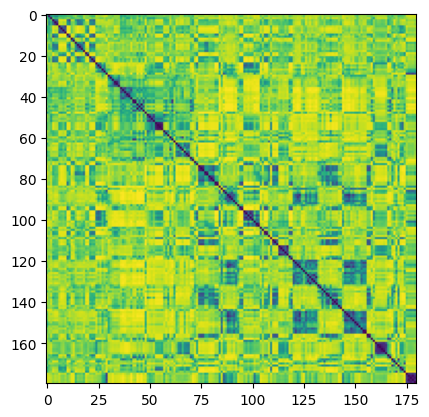

In [14]:
plt.imshow(dissimilarity, cmap='viridis')

Матрица сходств

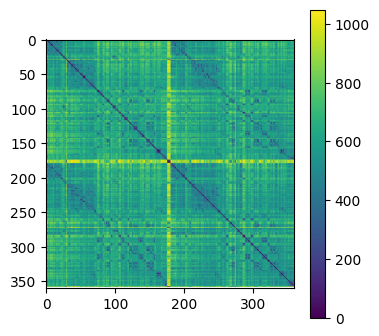

In [5]:
K = np.concatenate((Ktr, Kte), axis=0)
Y = np.concatenate((Ytr, Yte), axis=0)


# Compute the distance matrix
dtw_dist = dtw_ndim.distance_matrix_fast(K)

# Plot the distance matrix
plt.figure(figsize=(4,4))
plt.imshow(dtw_dist, cmap='viridis')
plt.colorbar()

plt.show()

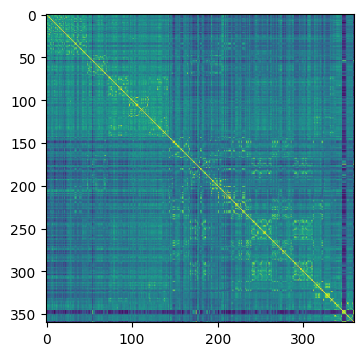

In [10]:
dtw_sim = 1.0 - dtw_dist/dtw_dist.max()

# Plot the similarity matrix
idx_sorted = np.argsort(Y[:,0])
dtw_sim_sorted = dtw_sim[:,idx_sorted][idx_sorted,:]
fig =  plt.figure(figsize=(4,4))
plt.imshow(dtw_sim_sorted)

In [19]:
sim_trtr = dtw_sim[:Xtr.shape[0], :Xtr.shape[0]]
print(sim_trtr.shape)

sim_tetr = dtw_sim[Xtr.shape[0]:, :Xtr.shape[0]]
print(sim_tetr.shape)

(180, 180)
(180, 180)


### 4.1 Классификация с помощью классификатора SVC

In [24]:
s = time.time()
clf = svm.SVC(kernel='precomputed', C=1).fit(Ktr, Ytr.ravel())
train_time = time.time() - s
y_pred = clf.predict(Kte)
accuracy = accuracy_score(Yte.ravel(), y_pred)
f1 = f1_score(Yte.ravel(), y_pred, average='macro')
print(f"Accuracy: {accuracy*100:.2f}%, F1_score: {f1*100:.2f}%", f"Время обучения и тестирования: {time.time() - s}")


Accuracy: 80.00%, F1_score: 79.90% Время обучения и тестирования: 0.0059871673583984375


### 4.2 Классификацию с помощью классификатора $k$-NN

In [ ]:
dtw_trtr = dtw_dist[:Xtr.shape[0], :Xtr.shape[0]]
dtw_tetr = dtw_dist[Xtr.shape[0]:, :Xtr.shape[0]]

In [25]:
s = time.time()
neigh = KNeighborsClassifier(n_neighbors=3, metric='precomputed') # specify k=3
neigh.fit(Ktr, Ytr.ravel())
y_pred = neigh.predict(Kte)
accuracy = accuracy_score(Yte.ravel(), y_pred)
f1 = f1_score(Yte.ravel(), y_pred, average='macro')
print(f"Accuracy: {accuracy*100:.2f}%, F1_score: {f1*100:.2f}%", f"Время обучения и тестирования: {time.time() - s} сек.")

Accuracy: 5.00%, F1_score: 4.25% Время обучения и тестирования: 0.005320310592651367 сек.


### 5. Иерархическая кластеризация

In [27]:
X_vectors = Xtr.reshape(Xtr.shape[0], -1)

X_final = StandardScaler().fit_transform(X_vectors)

Dist = dissimilarity
distArray = ssd.squareform(Dist)

# Compute the hierarchy of clusters
Z = linkage(distArray, 'ward')

In [30]:
partition_1 = fcluster(Z, t=0.1, criterion="distance")
print("Partition 1: %d clusters"%len(np.unique(partition_1)))

partition_2 = fcluster(Z, t=290, criterion="distance")
print("Partition 1: %d clusters"%len(np.unique(partition_2)))

Partition 1: 157 clusters
Partition 1: 1 clusters


### 6. Дендограмма

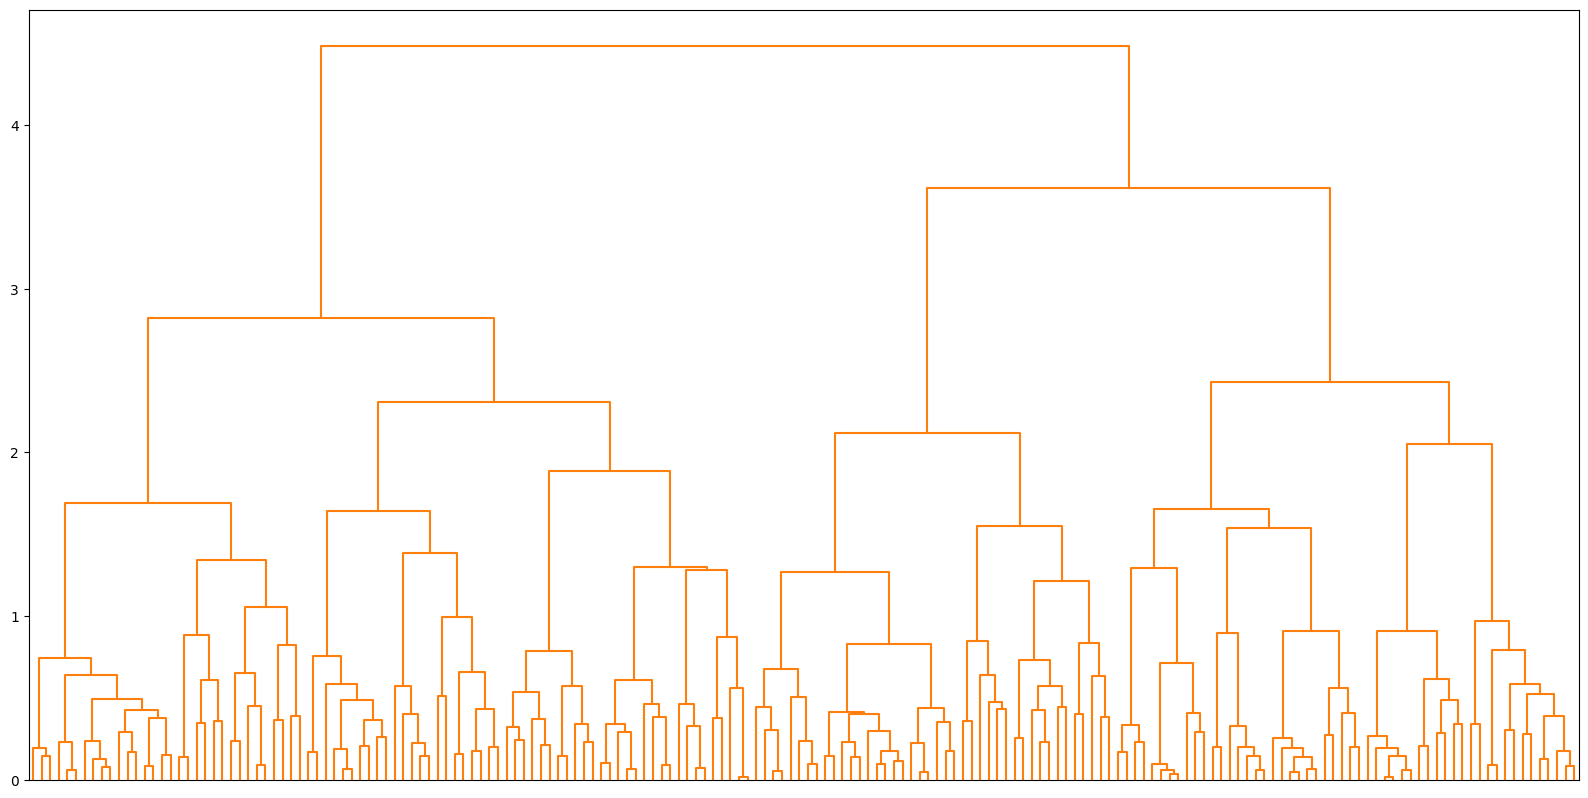

In [31]:
fig = plt.figure(figsize=(20, 10))
dn = dendrogram(Z, color_threshold=30, above_threshold_color='k',
                show_leaf_counts=False)
plt.xticks([])
plt.show()

In [32]:
partition_1 = fcluster(Z, t=1.5, criterion="distance")
print("Partition 1: %d clusters"%len(np.unique(partition_1)))

partition_2 = fcluster(Z, t=1, criterion="distance")
print("Partition 1: %d clusters"%len(np.unique(partition_2)))

Partition 1: 14 clusters
Partition 1: 22 clusters


In [34]:
def plot_clusters(data, clusters=None, title=None, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    color = 'gray' if clusters is None else plt.cm.tab10(clusters)
    ax.scatter(data[:, 0], data[:, 1], c=color, s=15, alpha=0.5)
    ax.set_xticks(())
    ax.set_yticks(())
    ax.spines[['right', 'left', 'top', 'bottom']].set_visible(False)
    ax.set_title(title)

### 7. Снижение размерности

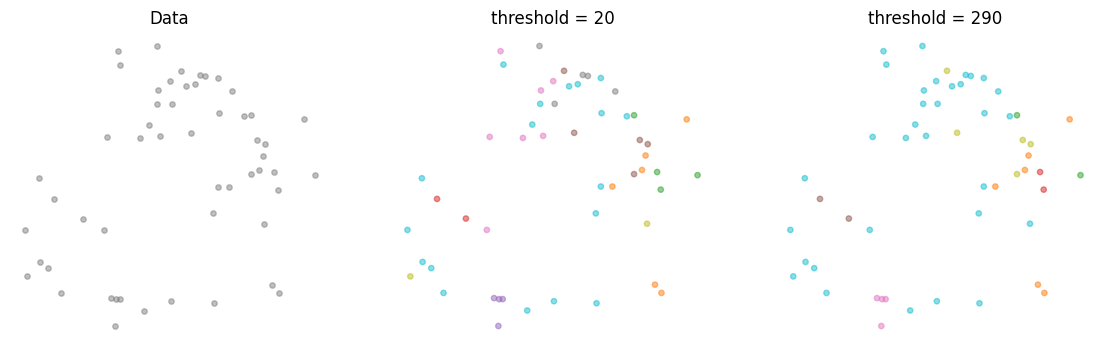

In [35]:
_, axes = plt.subplots(1,3, figsize=(14,4))
plot_clusters(X_final, title="Data", ax=axes[0])
plot_clusters(X_final, title="threshold = 20", clusters=partition_1, ax=axes[1])
plot_clusters(X_final, title="threshold = 290", clusters=partition_2, ax=axes[2])

In [38]:
print(f"DTW-based clustering NMI: {v_measure_score(partition_1, Ytr.ravel()):.2f}")

DTW-based clustering NMI: 0.54


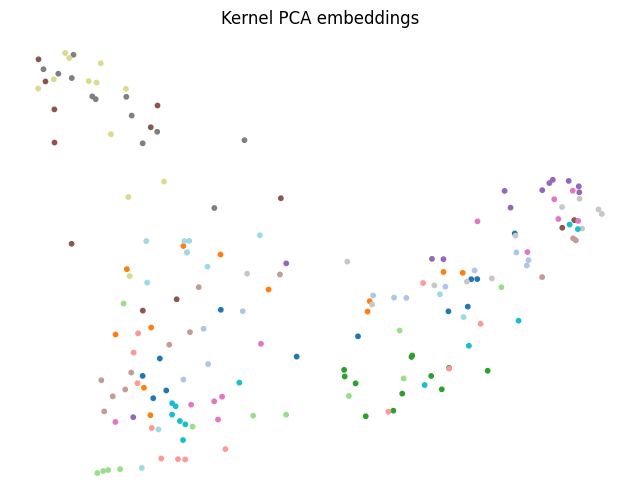

In [42]:
kpca = KernelPCA(n_components=2, kernel='precomputed')
embeddings_pca = kpca.fit_transform(Ktr)

fig =  plt.figure(figsize=(8,6))
plt.scatter(embeddings_pca[:,0], embeddings_pca[:,1], c=Ytr.ravel(), s=10, cmap='tab20')
plt.title("Kernel PCA embeddings")
plt.gca().spines[['right', 'left', 'top', 'bottom']].set_visible(False)
plt.xticks(())
plt.yticks(());

## Упражнение 3

1. Вычислите RC-вложения.
2. Получите матрицу сходства и различия из представлений MTS.

Повторите пункты 4–7 из предыдущих упражнений.

In [7]:
Xtr, Ytr, Xte, Yte = DataLoader().get_data('Libras')

Loaded Libras dataset.
Number of classes: 15
Data shapes:
  Xtr: (180, 45, 2)
  Ytr: (180, 1)
  Xte: (180, 45, 2)
  Yte: (180, 1)


In [21]:
X  = np.concatenate((Xtr, Xte), axis=0)
Y = np.concatenate((Ytr, Yte), axis=0)

### RC - вложения

In [23]:
H_bi = Reservoir(n_internal_units=300).get_states(X, bidir=True)
print(f"Bidir\n  H: {H_bi.shape}")

Bidir
  H: (360, 45, 600)


In [24]:
H_red = tensorPCA(n_components=20).fit_transform(H_bi)
print(f"H_red: {H_red.shape}")

H_red: (360, 45, 20)


In [25]:
rx_last = H_red[:,-1,:]
print(f"rx_last: {rx_last.shape}")

rx_last: (360, 20)


In [26]:
res_pred = Ridge(alpha=1.0)

coeff, biases = [], []
for i in range(H_red.shape[0]):
    res_pred.fit(H_red[i, 0:-1, :], H_red[i, 1:, :])
    coeff.append(res_pred.coef_.ravel())
    biases.append(res_pred.intercept_.ravel())
rx_res = np.concatenate((np.vstack(coeff), np.vstack(biases)), axis=1)

print(f"rx_res: {rx_res.shape}") # [N, R*(R+1)]

rx_res: (360, 420)


In [27]:
rx_res

array([[ 0.67801162, -0.0104431 ,  0.04899932, ..., -0.49281726,
         0.3674383 , -0.07552549],
       [ 0.85101577,  0.0620436 , -0.13655321, ...,  0.03557025,
         0.01886567,  0.13136348],
       [ 0.88943995,  0.06094124, -0.06462167, ..., -0.04432571,
         0.03597974, -0.15054723],
       ...,
       [ 0.85219696, -0.07927536,  0.04091584, ..., -0.02014552,
        -0.57791502, -0.44072557],
       [ 0.40290051,  0.10840915,  0.09371394, ..., -0.23352887,
         0.11683364, -0.01999435],
       [ 0.33359025, -0.16170246,  0.03635134, ..., -0.03968574,
         0.02759483,  0.11378667]])

### 2. Матрица сходств и различий

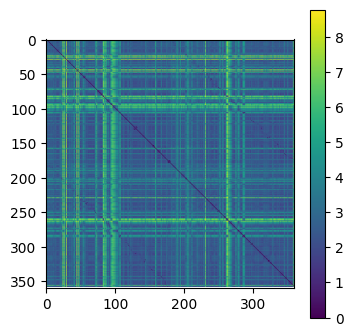

In [28]:
# Compute the distance matrix
dtw_dist = dtw_ndim.distance_matrix_fast(rx_res)

# Plot the distance matrix
plt.figure(figsize=(4,4))
plt.imshow(dtw_dist, cmap='viridis')
plt.colorbar()

plt.show()

Матрица различий 

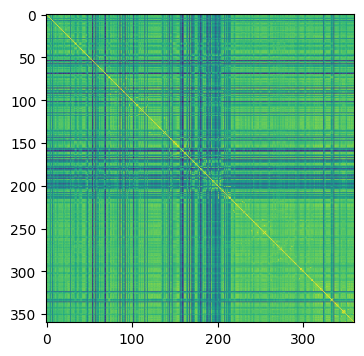

In [30]:
dtw_sim = 1.0 - dtw_dist/dtw_dist.max()

# Plot the similarity matrix
idx_sorted = np.argsort(Y[:,0])
dtw_sim_sorted = dtw_sim[:,idx_sorted][idx_sorted,:]
fig =  plt.figure(figsize=(4,4))
plt.imshow(dtw_sim_sorted)

In [31]:
sim_trtr = dtw_sim[:Xtr.shape[0], :Xtr.shape[0]]
print(sim_trtr.shape)

sim_tetr = dtw_sim[Xtr.shape[0]:, :Xtr.shape[0]]
print(sim_tetr.shape)

(180, 180)
(180, 180)


### 4.1 Классификация с помощью классификатора SVC

In [32]:
s = time.time()
clf = svm.SVC(kernel='precomputed', C=1).fit(sim_trtr, Ytr.ravel())
f = time.time() - s
y_pred = clf.predict(sim_tetr)
accuracy = accuracy_score(Yte.ravel(), y_pred)
f1 = f1_score(Yte.ravel(), y_pred, average='macro')
print(f"Accuracy: {accuracy*100:.2f}%, F1_score: {f1*100:.2f}%", f"Время обучения и тестирования: {time.time() - s}")


Accuracy: 43.89%, F1_score: 42.30% Время обучения и тестирования: 0.011102914810180664


### 4.2 Классификацию с помощью классификатора $k$-NN

In [33]:
# In this case we use the DTW distance directly.
dtw_trtr = dtw_dist[:Xtr.shape[0], :Xtr.shape[0]]
dtw_tetr = dtw_dist[Xtr.shape[0]:, :Xtr.shape[0]]

In [34]:
s = time.time()
neigh = KNeighborsClassifier(n_neighbors=3, metric='precomputed') # specify k=3
neigh.fit(dtw_trtr, Ytr.ravel())
y_pred = neigh.predict(dtw_tetr)
accuracy = accuracy_score(Yte.ravel(), y_pred)
f1 = f1_score(Yte.ravel(), y_pred, average='macro')
print(f"Accuracy: {accuracy*100:.2f}%, F1_score: {f1*100:.2f}%", f"Время обучения и тестирования: {time.time() - s} сек.")

Accuracy: 53.89%, F1_score: 53.06% Время обучения и тестирования: 0.01163792610168457 сек.


### 5. Иерархическая кластеризация

In [35]:
X_vectors = Xtr.reshape(Xtr.shape[0], -1)

X_final = StandardScaler().fit_transform(X_vectors)

Dist = pairwise_distances(X_final, metric="sqeuclidean")
distArray = ssd.squareform(Dist)

# Compute the hierarchy of clusters
Z = linkage(distArray, 'ward')

In [37]:
partition_1 = fcluster(Z, t=50, criterion="distance")
print("Partition 1: %d clusters"%len(np.unique(partition_1)))

partition_2 = fcluster(Z, t=290, criterion="distance")
print("Partition 1: %d clusters"%len(np.unique(partition_2)))

Partition 1: 68 clusters
Partition 1: 15 clusters


In [38]:
def plot_clusters(data, clusters=None, title=None, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    color = 'gray' if clusters is None else plt.cm.tab10(clusters)
    ax.scatter(data[:, 0], data[:, 1], c=color, s=15, alpha=0.5)
    ax.set_xticks(())
    ax.set_yticks(())
    ax.spines[['right', 'left', 'top', 'bottom']].set_visible(False)
    ax.set_title(title)

### 6. Дендограмма

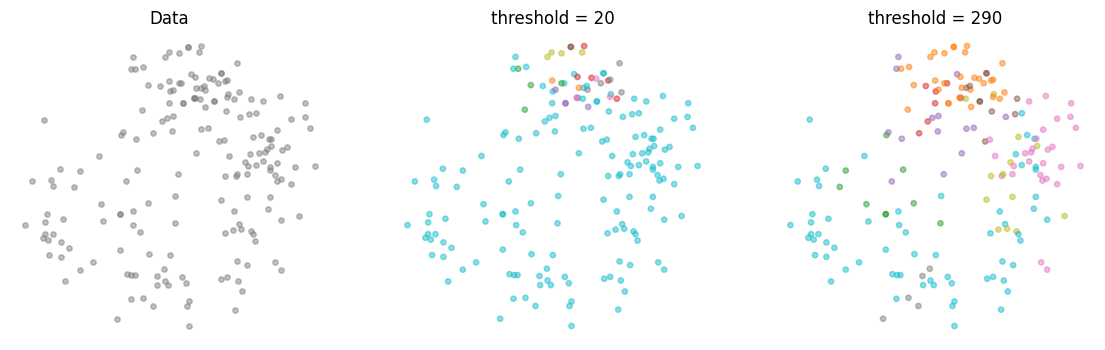

In [39]:
_, axes = plt.subplots(1,3, figsize=(14,4))
plot_clusters(X_final, title="Data", ax=axes[0])
plot_clusters(X_final, title="threshold = 20", clusters=partition_1, ax=axes[1])
plot_clusters(X_final, title="threshold = 290", clusters=partition_2, ax=axes[2])

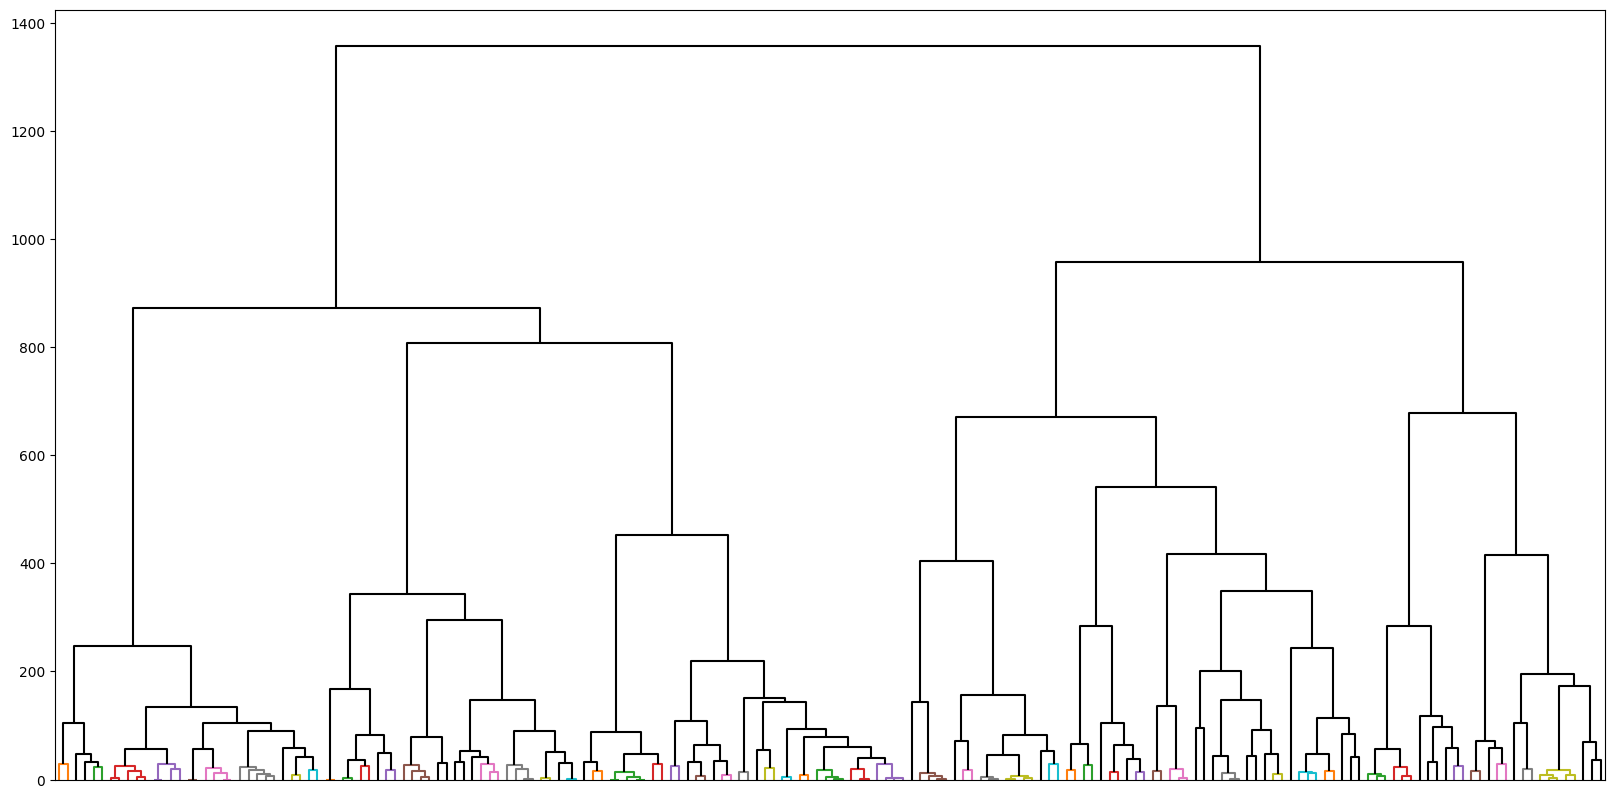

In [40]:
fig = plt.figure(figsize=(20, 10))
dn = dendrogram(Z, color_threshold=30, above_threshold_color='k',
                show_leaf_counts=False)
plt.xticks([])
plt.show()

In [41]:
partition = fcluster(Z, t=350, criterion="distance")
print(f"Found {len(np.unique(partition))} clusters")

Found 12 clusters


In [42]:
print(f"DTW-based clustering NMI: {v_measure_score(partition, Ytr.ravel()):.2f}")

DTW-based clustering NMI: 0.58


### 7. Снижение размерности

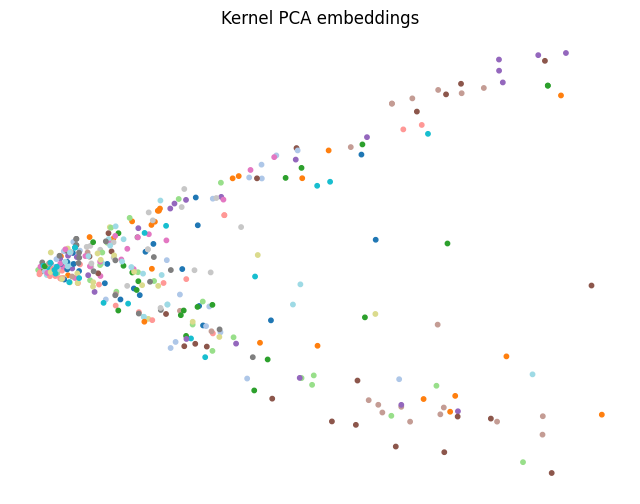

In [43]:
kpca = KernelPCA(n_components=2, kernel='precomputed')
embeddings_pca = kpca.fit_transform(dtw_sim)

fig =  plt.figure(figsize=(8,6))
plt.scatter(embeddings_pca[:,0], embeddings_pca[:,1], c=Y.ravel(), s=10, cmap='tab20')
plt.title("Kernel PCA embeddings")
plt.gca().spines[['right', 'left', 'top', 'bottom']].set_visible(False)
plt.xticks(())
plt.yticks(());